In [5]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)  # modern rng style

def custom_least_squares(X, Y):

    X = np.array(X, dtype=float)
    Y = np.array(Y, dtype=float)
    n = len(X)

    sum_x  = np.sum(X)
    sum_y  = np.sum(Y)
    sum_x2 = np.sum(X**2)
    sum_xy = np.sum(X*Y)

#used the basic structure that was in the slides for making the sum structure
    denom = n*sum_x2 - (sum_x**2)
    if denom == 0:
        raise ValueError("Denominator is zero (X values might all be the same).")
    m = (n*sum_xy - sum_x*sum_y) / denom
    c = (sum_y - m*sum_x) / n

    return m, c

def numpy_least_squares(X, Y):
    X = np.array(X, dtype=float)
    Y = np.array(Y, dtype=float)
    A = np.vstack([X, np.ones(len(X))]).T
    m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
    return m, c

Custom Least Squares Slope: 0.95
Intercept: 0.5899999999999999
Numpy Least Squares Slope: 0.9500000000000001
Intercept: 0.5900000000000001
Difference between m: 1.1102230246251565e-16
Difference between c: 2.220446049250313e-16


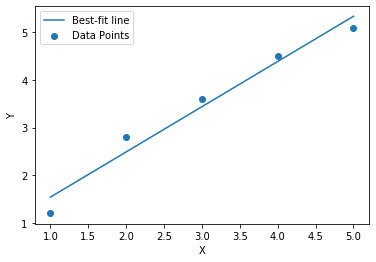

In [8]:
X = np.array([1, 2, 3, 4, 5], dtype=float)
Y = np.array([1.2, 2.8, 3.6, 4.5, 5.1], dtype=float)

m_my, c_my = custom_least_squares(X, Y)

m_np, c_np = numpy_least_squares(X, Y)

print("Custom Least Squares Slope:", m_my)
print("Intercept:", c_my)
print("Numpy Least Squares Slope:", m_np)
print("Intercept:", c_np)
print("Difference between m:", abs(m_my - m_np))
print("Difference between c:", abs(c_my - c_np))

# Plot (use my line just to show it works)
Y_line = m_my*X + c_my

plt.figure()
plt.scatter(X, Y, label="Data Points")
plt.plot(X, Y_line, label="Best-fit line")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

Comparison:
Custom slope: -0.15266773548119944
Custom intercept: 2.9426830851606964
Numpy slope: -0.15266773548120033
Numpy intercept: 2.9426830851606987


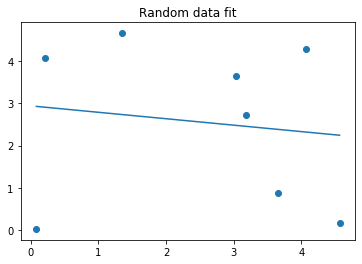

Synthetic data comparison:
True line:  y = 2.5 *x + 1.0
Custom true line fit:  y = 2.5013786679087167 *x + 1.007870887497919
Numpy true line fit:  y = 2.501378667908716 *x + 1.0078708874979185
Largest residual: 0.9892011815004205 at x = 0.1
Smallest residual: 0.005787629856825571 at x = 0.76


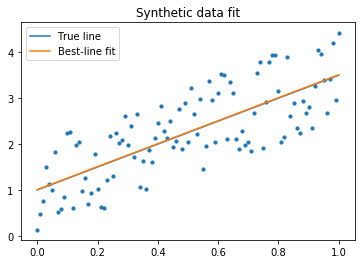

In [9]:
Xr = rng.random(8) * 5
Yr = rng.random(8) * 5

idx = np.argsort(Xr)
Xr = Xr[idx]
Yr = Yr[idx]

m_my, c_my = custom_least_squares(Xr, Yr)
m_np, c_np = numpy_least_squares(Xr, Yr)

print("Comparison:")
print("Custom slope:", m_my,)
print("Custom intercept:", c_my)
print("Numpy slope:", m_np)
print("Numpy intercept:", c_np)

plt.figure()
plt.scatter(Xr, Yr)
plt.plot(Xr, m_my*Xr + c_my)
plt.title("Random data fit")
plt.show()

m_true = 2.5
b_true = 1.0

X = np.arange(0, 1.01, 0.01)

err = rng.random(len(X))
sign = rng.choice([-1,1], len(X))
Y = m_true*X + b_true + sign*err

m_my, c_my = custom_least_squares(X, Y)
m_np, c_np = numpy_least_squares(X, Y)

print("Synthetic data comparison:")
print("True line:  y =", m_true, "*x +", b_true)
print("Custom true line fit:  y =", m_my, "*x +", c_my)
print("Numpy true line fit:  y =", m_np, "*x +", c_np)

Yhat = m_my*X + c_my
res = Y - Yhat

i_max = np.argmax(np.abs(res))
i_min = np.argmin(np.abs(res))

print("Largest residual:", res[i_max], "at x =", X[i_max])
print("Smallest residual:", res[i_min], "at x =", X[i_min])

plt.figure()
plt.scatter(X, Y, s=10)
plt.plot(X, m_true*X + b_true, label="True line")
plt.plot(X, Yhat, label="Best-line fit")
plt.legend()
plt.title("Synthetic data fit")
plt.show()

#I needed to use ChatGPT to know how to do random vector test. About 50 percent of this
#cell is structured by using its defined structure. More specifically, I 
#did not know how to find the residuals or get them to compare. I also learned about
#np.argsort